<br>Вступ до комп’ютерного зору
<br>Лабораторна робота No2
<br>Фiльтрацiя зображень
<br>Метою цiєї лабораторної роботи є отримання навичок роботи з методами
просторової фiльтрацiї зображень.

Завантажуємо потрібні бібліотеки

In [37]:
import numpy as np
import cv2
from matplotlib import pyplot as plt 

Завантажуємо наше фото

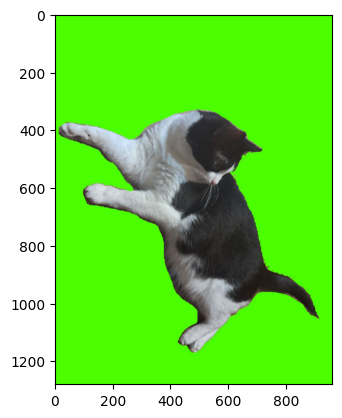

In [38]:
image = cv2.imread('Diva1.jpg')
image= image[:, :, ::-1]
rows = image.shape[0]
cols = image.shape[1]
plt.imshow(image)


Обираємо один канал кольорів, для зручності

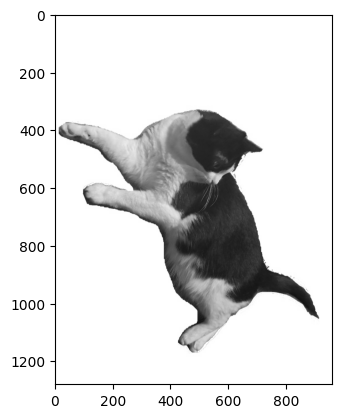

In [39]:
b,r,g = cv2.split(image)
plt.imshow(r, cmap='gray')

Зсув зображення на 10 пiкселiв вправо та 20 вниз

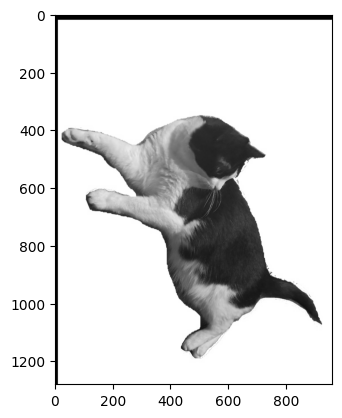

In [59]:

dx = 10  # зсув вправо
dy = 20  # зсув вниз

# Створюємо δ-ядро (для наочності)
kernel = np.zeros((dy+1, dx+1), dtype=np.float32)
kernel[dy, dx] = 1.0  # одиниця там, куди зсувати пікселі

# Ініціалізуємо результат
shifted = np.zeros_like(r, dtype=np.float32)

# Реалізуємо свертку δ-ядра через індексацію
shifted[dy:, dx:] = r[:rows-dy, :cols-dx]

# Обрізаємо і перетворюємо на uint8
shifted = np.clip(shifted, 0, 255).astype(np.uint8)

plt.imshow(shifted, cmap='gray')

In [60]:
print(kernel)

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


Iнверсiя

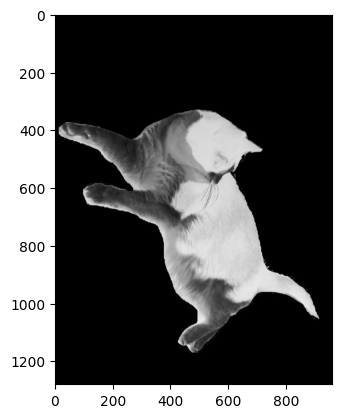

In [63]:
kernel = np.array([[-1]], dtype=np.float32)
bias = 255

inv = r.astype(np.float32) * kernel[0,0] + bias
inv = np.clip(inv, 0, 255).astype(np.uint8)
plt.imshow(inv, cmap='gray')

In [64]:
print(kernel)

[[-1.]]


Згладжування по Гауссу

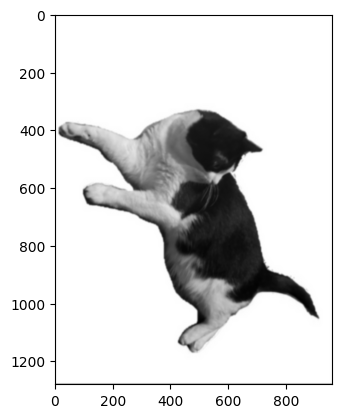

In [66]:
kernel_size = 51   # ядро 11x11
sigma = 2.0        # стандартне відхилення
pad = kernel_size // 2
blurred = np.zeros_like(r, dtype=np.float32)
ax = np.linspace(-(kernel_size-1)//2, (kernel_size-1)//2, kernel_size)
xx, yy = np.meshgrid(ax, ax)

kernel = np.exp(-(xx**2 + yy**2)/(2*sigma**2))
kernel = kernel / np.sum(kernel) 

padded = np.pad(r, pad_width=pad, mode='constant', constant_values=0)

for i in range(rows):
    for j in range(cols):
        region = padded[i:i+kernel_size, j:j+kernel_size]
        blurred[i,j] = np.sum(region * kernel)

blurred = blurred.astype(np.uint8)
plt.imshow(blurred, cmap='gray')   


In [67]:
print(kernel)

[[5.51121486e-70 2.51942274e-67 8.96976625e-65 ... 8.96976625e-65
  2.51942274e-67 5.51121486e-70]
 [2.51942274e-67 1.15174079e-64 4.10048122e-62 ... 4.10048122e-62
  1.15174079e-64 2.51942274e-67]
 [8.96976625e-65 4.10048122e-62 1.45987244e-59 ... 1.45987244e-59
  4.10048122e-62 8.96976625e-65]
 ...
 [8.96976625e-65 4.10048122e-62 1.45987244e-59 ... 1.45987244e-59
  4.10048122e-62 8.96976625e-65]
 [2.51942274e-67 1.15174079e-64 4.10048122e-62 ... 4.10048122e-62
  1.15174079e-64 2.51942274e-67]
 [5.51121486e-70 2.51942274e-67 8.96976625e-65 ... 8.96976625e-65
  2.51942274e-67 5.51121486e-70]]


Розмиття "рух по дiагоналi"

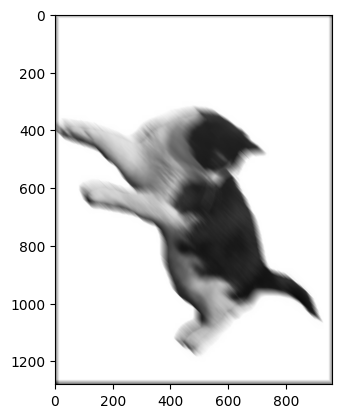

In [69]:
kernel_size = 31
pad = kernel_size // 2
kernel = np.zeros((kernel_size, kernel_size), dtype=np.float32)
np.fill_diagonal(kernel, 1.0)
kernel /= kernel.sum() 
padded = np.pad(r, pad_width=pad, mode='constant', constant_values=0)
blur_diag = np.zeros_like(r, dtype=np.float32)
for i in range(rows):
    for j in range(cols):
        region = padded[i:i+kernel_size, j:j+kernel_size]
        blur_diag[i,j] = np.sum(region * kernel)

blur_diag = np.clip(blur_diag,0,255).astype(np.uint8)
plt.imshow(blur_diag, cmap='gray')

In [70]:
print(kernel)

[[0.03225806 0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.        ]
 [0.         0.03225806 0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.        ]
 [0.         0.         0.03225806 0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.        ]
 [0.         0.         0.         0.03225806 0.         0

Пiдвищення рiзкостi

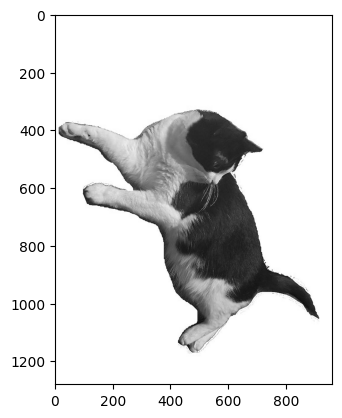

In [55]:
sharpen_kernel = np.array([[0,-1,0],
                           [-1,5,-1],
                           [0,-1,0]], dtype=np.float32)
pad = 1
sharp = np.zeros_like(r, dtype=np.float32)
padded = np.pad(r, pad_width=pad, mode='constant', constant_values=0)
for i in range(rows):
    for j in range(cols):
        region = padded[i:i+3, j:j+3]
        sharp[i,j] = np.sum(region * sharpen_kernel)

sharp = np.clip(sharp,0,255).astype(np.uint8)

plt.imshow(sharp, cmap='gray')

Фiльтр Собеля

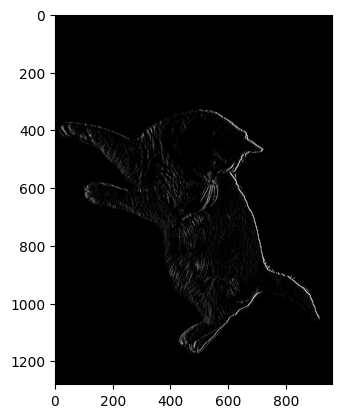

In [47]:
sobel_x = np.array([[-1,0,1],
                    [-2,0,2],
                    [-1,0,1]], dtype=np.float32)
pad = 1
padded = np.pad(r, pad_width=pad, mode='constant', constant_values=0)
sobel_img = np.zeros_like(r, dtype=np.float32)
for i in range(rows):
    for j in range(cols):
        region = padded[i:i+3,j:j+3]
        sobel_img[i,j] = np.sum(region*sobel_x)

sobel_img = np.clip(sobel_img,0,255).astype(np.uint8)
plt.imshow(sobel_img, cmap='gray')

Фiльтр границi

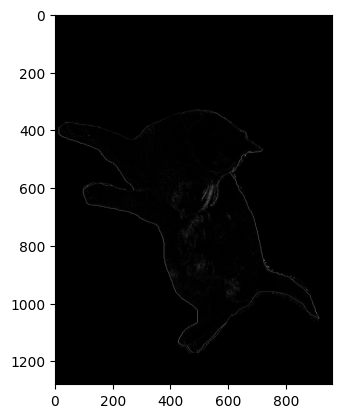

In [48]:
laplacian_kernel = np.array([[0,1,0],
                             [1,-4,1],
                             [0,1,0]], dtype=np.float32)

pad = 1
padded = np.pad(r, pad, mode='constant', constant_values=0)
edge_img = np.zeros_like(r, dtype=np.float32)

for i in range(rows):
    for j in range(cols):
        region = padded[i:i+3,j:j+3]
        edge_img[i,j] = np.sum(region*laplacian_kernel)

edge_img = np.clip(edge_img,0,255).astype(np.uint8)
plt.imshow(edge_img, cmap='gray')

Фільтр Робертса - фільтр на свій вибір

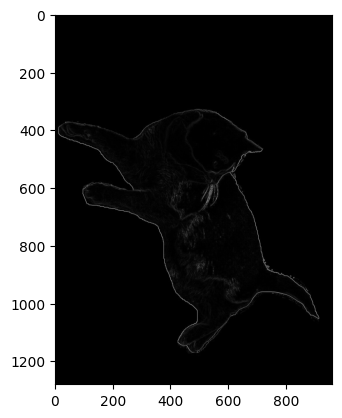

In [50]:

Gx = np.array([[1, 0],
               [0, -1]], dtype=np.float32)

Gy = np.array([[0, 1],
               [-1, 0]], dtype=np.float32)

r = r.astype(np.float32)

rob = np.zeros_like(r)

for i in range(rows - 1):
    for j in range(cols - 1):
        gx = r[i,j] - r[i+1,j+1]
        gy = r[i,j+1] - r[i+1,j]
        rob[i,j] = np.sqrt(gx*gx + gy*gy)

rob = np.clip(rob, 0, 255).astype(np.uint8)
plt.imshow(rob, cmap='gray')
plt.show()

Kuwahara filter - фільтр на свій вибір

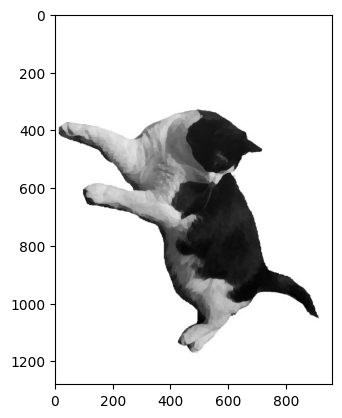

In [49]:
#kernel = np.zeros((5,5), dtype=np.float32)
#np.fill_diagonal(kernel, 0.5)  # половина впливу по діагоналі
k = 5  # половина розміру вікна, повне вікно буде 2k+1 = 11
pad = k
padded = np.pad(r, pad, mode='reflect')  # відображення країв

kuwahara = np.zeros_like(r, dtype=np.float32)

for i in range(rows):
    for j in range(cols):
        # Вікно навколо пікселя
        window = padded[i:i+2*k+1, j:j+2*k+1]
        mid = k

        # 4 квадранти
        q1 = window[0:mid+1, 0:mid+1]       # верхній лівий
        q2 = window[0:mid+1, mid:]          # верхній правий
        q3 = window[mid:, 0:mid+1]          # нижній лівий
        q4 = window[mid:, mid:]             # нижній правий

        quadrants = [q1, q2, q3, q4]

        # обчислюємо дисперсію та середнє
        mean_vals = [np.mean(q) for q in quadrants]
        var_vals = [np.var(q) for q in quadrants]

        # обираємо середнє з найменшою дисперсією
        kuwahara[i,j] = mean_vals[np.argmin(var_vals)]

kuwahara = np.clip(kuwahara,0,255).astype(np.uint8)
plt.imshow(kuwahara, cmap='gray')